
# <span style="color:rgb(213,80,0)">ROZWIĄZYWANIE RÓWNAŃ NIELINIOWYCH</span>

## PARAMETRY LOKALNEJ ZBIEŻNOŚCI

Na początek zajmijmy się współczynnikiem lokalnej zbieżności $C$:

$$\Delta_{i+1} = C \cdot \Delta_i^{\rho}$$

W celu zrozumienia czym jest współczynnik lokalnej zbieżności posłużymy się dwiema metodami o wykładniku lokalnej zbieżności $\rho = 1$ — metodą bisekcji i metodą *regula falsi*. Jedyna różnica między tymi dwiema metodami polega na różnicy we współczynniku lokalnej zbieżności i jego ewentualnej zależności od funkcji i punktu startowego.

Wyrysujmy zbieżność naszego algorytmu dla tych dwóch przypadków osobno:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import warnings

def calculateBisectionSolution(f, a, b, opts=None):
    if opts is None:
        opts = {}
    imax = opts.get('imax', 1000000)
    return_all = opts.get('return_all', False)
    TOL = opts.get('TOL', 1e-12)
    show_warnings = opts.get('warnings', True)
    
    if return_all:
        x = np.zeros(imax)
        x[0] = (a + b) / 2
        i = 0
        while (b - a) > TOL and i < imax - 1:
            if f(x[i]) == 0:
                break
            elif np.sign(f(x[i])) == np.sign(f(a)):
                a = x[i]
            else:
                b = x[i]
            i += 1
            x[i] = (a + b) / 2
        if show_warnings and i >= imax - 1:
            warnings.warn(f'Metoda nie zbiegła po {imax} iteracjach.')
        return x[:i+1]
    else:
        c = (a + b) / 2
        i = 0
        while (b - a) > TOL and i < imax:
            if f(c) == 0:
                break
            elif np.sign(f(c)) == np.sign(f(a)):
                a = c
            else:
                b = c
            c = (a + b) / 2
            i += 1
        root = c
    return root

def calculateFalsePositionSolution(f, a, b, opts=None):
    if opts is None:
        opts = {}
    imax = opts.get('imax', 1000000)
    return_all = opts.get('return_all', False)
    TOL = opts.get('TOL', 1e-12)
    show_warnings = opts.get('warnings', True)
    
    if return_all:
        x = np.zeros(imax)
        fx1, fx2 = f(a), f(b)
        if fx1 * fx2 >= 0:
            raise ValueError('Błędny wybór nawiasu - f(a) i f(b) muszą mieć różne znaki.')
        c = b - (fx2 * (b - a)) / (fx2 - fx1)
        x[0] = c
        fc = f(c)
        x1, x2, fx1, fx2 = a, b, fx1, fx2
        i = 0
        c_old = 0
        while abs(c - c_old) > TOL and i < imax - 1:
            if fc < 0:
                x1, fx1 = c, fc
            else:
                x2, fx2 = c, fc
            c_old = c
            c = x1 - (fx1 * (x1 - x2)) / (fx1 - fx2)
            i += 1
            x[i] = c
            fc = f(c)
        if show_warnings and i >= imax - 1:
            warnings.warn(f'Metoda nie zbiegła po {imax} iteracjach.')
        return x[:i+1]
    else:
        fx1, fx2 = f(a), f(b)
        if fx1 * fx2 >= 0:
            raise ValueError('Błędny wybór nawiasu - f(a) i f(b) muszą mieć różne znaki.')
        c = b - (fx2 * (b - a)) / (fx2 - fx1)
        fc = f(c)
        x1, x2, fx1, fx2 = a, b, fx1, fx2
        i = 0
        c_old = 0
        while abs(c - c_old) > TOL and i < imax:
            if fc < 0:
                x1, fx1 = c, fc
            else:
                x2, fx2 = c, fc
            c_old = c
            c = x1 - (fx1 * (x1 - x2)) / (fx1 - fx2)
            fc = f(c)
            i += 1
    return c

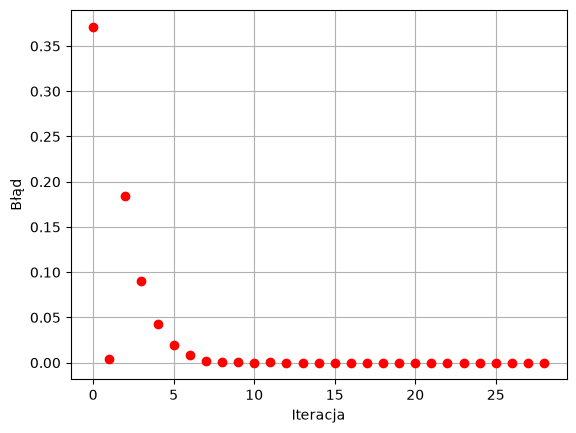

In [2]:
# Do rozwiązania przyjmiemy funkcję o teoretycznym pierwiastku
f = lambda x: x**50 * np.exp(-x) - 100
true_root = 1.121346658722935

# Pierwszy test wykonamy dla metody bisekcji
options = {'imax': 100, 'return_all': True, 'TOL': 1e-8, 'warnings': True}

# Ustawiamy właściwe warunki startowe dla bisekcji
a, b = 0, 1.5

# Uruchamiamy implementację
resultsBisection = calculateBisectionSolution(f, a, b, options)

# Obliczamy błąd rozwiązania w kolejnych iteracjach
errorBisection = np.abs(resultsBisection - true_root)

plt.figure()
plt.plot(errorBisection, 'ro')
plt.xlabel('Iteracja')
plt.ylabel('Błąd')
plt.grid(True)
plt.show()

/tmp/ipykernel_52709/1869438818.py:74: UserWarning: Metoda nie zbiegła po 100 iteracjach.
  warnings.warn(f'Metoda nie zbiegła po {imax} iteracjach.')


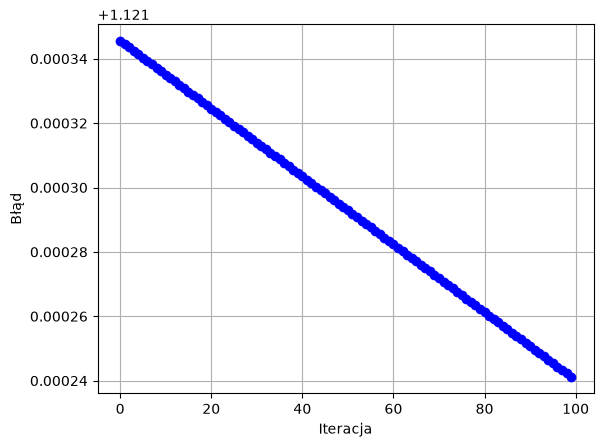

In [3]:
# Powtarzamy procedurę dla metody regula falsi
resultsFalsePosition = calculateFalsePositionSolution(f, a, b, options)
errorFalsePosition = np.abs(resultsFalsePosition - true_root)

plt.figure()
plt.plot(errorFalsePosition, 'bo')
plt.xlabel('Iteracja')
plt.ylabel('Błąd')
plt.grid(True)
plt.show()


Zastanówmy się teraz jak interpretować te wyniki oddzielnie. Wiemy, że obie metody mają zbieżność liniową $\rho = 1$, a jednak wykresy błędu nie wyglądają liniowo. Aby to wyjaśnić przypomnijmy sobie definicję wykładnika lokalnej zbieżności:

$$\Delta_{i+1} = C \cdot \Delta_i^{\rho}$$

Aby zobaczyć liniową zależność należałoby wyrysować zależność między błędem w poprzedniej iteracji a błędem w obecnej. Natomiast my mamy wyrysowaną zależność błędu od numeru iteracji.

Wyrysujmy zatem wykres tak, żeby zobaczyć zależność liniową dla obu metod:

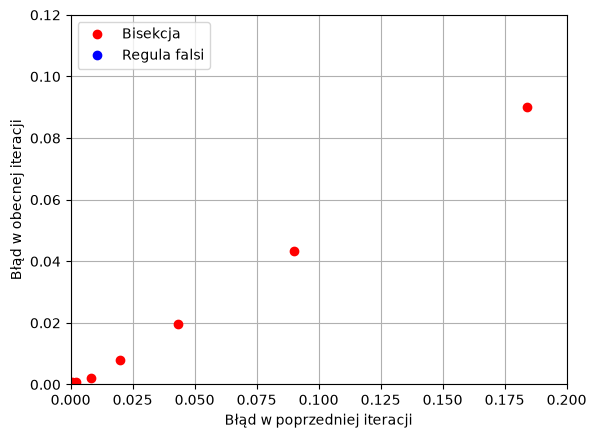

In [4]:
# Generacja wektorów błędów starych i nowych
oldBisection = errorBisection[:-1]
newBisection = errorBisection[1:]

oldFP = errorFalsePosition[:-1]
newFP = errorFalsePosition[1:]

plt.figure()
plt.plot(oldBisection, newBisection, 'ro', label='Bisekcja')
plt.plot(oldFP, newFP, 'bo', label='Regula falsi')
plt.xlabel('Błąd w poprzedniej iteracji')
plt.ylabel('Błąd w obecnej iteracji')
plt.grid(True)
plt.axis([0, 0.2, 0, 0.12])
plt.legend()
plt.show()

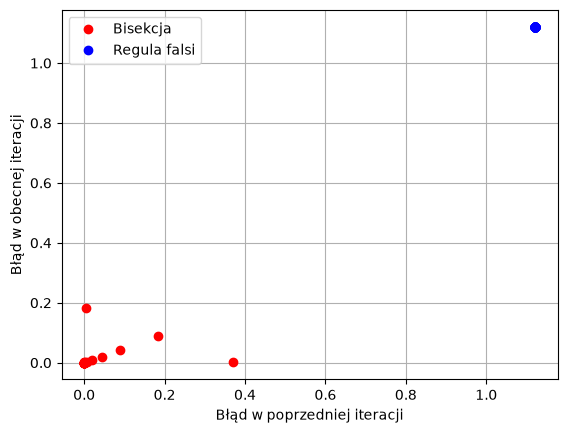

In [5]:
# Powiększona wersja wykresu — pełny zakres
plt.figure()
plt.plot(oldBisection, newBisection, 'ro', label='Bisekcja')
plt.plot(oldFP, newFP, 'bo', label='Regula falsi')
plt.xlabel('Błąd w poprzedniej iteracji')
plt.ylabel('Błąd w obecnej iteracji')
plt.grid(True)
plt.legend()
plt.show()

Jak widać zależność w obu przypadkach jest liniowa. Różnice w nachyleniu wydają się być niewielkie, ale są znaczące.

Zwróć na początek uwagę na wykres dla metody bisekcji (czerwony). Ta prosta ma dokładnie nachylenie 0.5 — unikalną cechą metody bisekcji jest to, że ta wartość nie zależy od danych wejściowych.

**ĆWICZENIE 1**

Zmodyfikuj powyższy kod, zawężając przedział startowy $[a, b]$ tak, aby leżał coraz bliżej jedynego pierwiastka tej funkcji ($x \approx 1.1213$), i porównaj, jak zmienia się liczba iteracji potrzebnych do osiągnięcia zadanej dokładności w zależności od szerokości przedziału startowego.

Wróć do oryginalnych ustawień ($a=0,\\; b=1.5,\\; \text{true\_root}=1.12...$). Wykonaj pierwszą część kodu powyżej.

Teraz zaobserwujemy kolejny efekt numeryczny:


Jak widzisz dla dalszych iteracji zależność liniowa się "rozpada". Dzieje się tak dlatego, że w przypadku liniowego, bardzo wolnozbieżnego algorytmu zachodzi ciągła propagacja błędu (taka o jakiej mówiliśmy w pierwszej części zajęć). Im więcej iteracji musi zrobić algorytm, tym bardziej początkowe błędy zaokrągleń i reprezentacji są propagowane przez algorytm. W skrajnym przypadku mogą nie pozwolić na uzyskanie wyniku w ogóle.

Błędy te nie podlegają redukcji w algorytmach iteracyjnych (zmniejszają one wyłącznie błędy metody). Dlatego poza wyjątkowymi sytuacjami, kiedy jakaś metoda jest liniowa, raczej jej nie stosujemy, chyba że ma jakieś bardzo przydatne właściwości, jak np. stały współczynnik zbieżności w przypadku bisekcji.

**ĆWICZENIE 2**

Wiedząc, że dla metody *regula falsi* współczynnik zbieżności jest uzależniony od funkcji oryginalnej zgodnie z wyrażeniem:

$$C = \frac{f^{\prime\prime}(y_{\infty})}{2 f^{\prime}(y_{\infty})}$$

Dobierz tak funkcję w powyższych kodach, aby metoda *regula falsi* dawała wynik zbieżności lepszy od metody bisekcji.

**ĆWICZENIE 2 (cont.)**

Powtórz ćwiczenie 1 tak, żeby metoda *regula falsi* była rozbieżna (w ogóle nie dawała wyniku).